<a href="https://colab.research.google.com/github/varshacode01/varshacode01/blob/main/Predicting_AVF_Maturation_Success.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Predicting AVF Maturation Success (Product Development/Materials)**

This model predicts AVF maturation success based on simulated patient and implant data. It demonstrates how patient factors (age, diabetes, vein diameter) and device design parameters (wrap thickness, porosity) could influence clinical outcomes. This kind of analysis can help guide design optimization and clinical trial focus.

Goal:
Use dummy patient + implant data to predict which patients are most likely to achieve successful AVF maturation

This project applies predictive modeling to explore how patient and device characteristics influence the likelihood of successful arteriovenous fistula (AVF) maturation when using SelfWrap. Using simulated patient and implant data — including age, diabetes status, vein diameter, and wrap properties — the model estimates the probability of maturation success. This type of analysis could support both clinical trial design and product optimization by highlighting which patient subgroups and material configurations are most associated with durable AVF outcomes.

              precision    recall  f1-score   support

           0       1.00      0.33      0.50         9
           1       0.89      1.00      0.94        51

    accuracy                           0.90        60
   macro avg       0.95      0.67      0.72        60
weighted avg       0.91      0.90      0.88        60



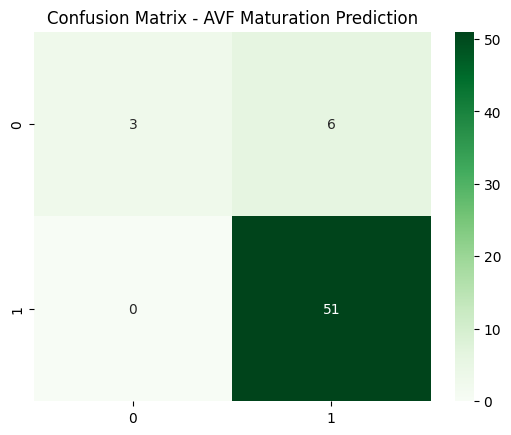

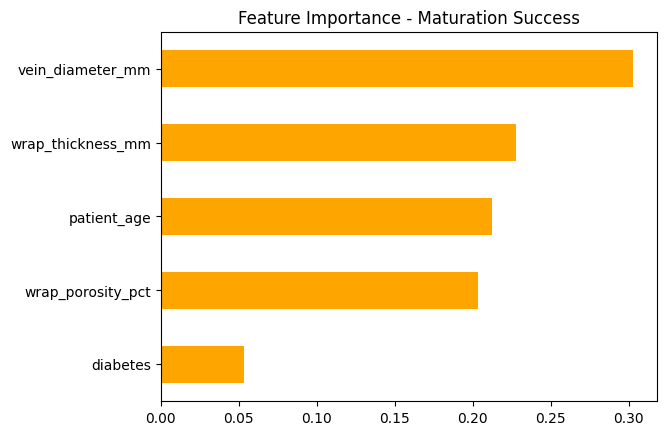

In [1]:
# Predicting AVF Maturation Success
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Simulate patient + implant data
np.random.seed(42)
n = 200
data = pd.DataFrame({
    "patient_age": np.random.randint(40, 80, n),
    "diabetes": np.random.choice([0, 1], n),
    "vein_diameter_mm": np.random.uniform(3.0, 7.0, n),
    "wrap_thickness_mm": np.random.uniform(0.25, 0.45, n),
    "wrap_porosity_pct": np.random.uniform(30, 55, n)
})

# Simulate outcome (1 = matured, 0 = failed)
data["matured"] = (
    (0.4 * data["vein_diameter_mm"] +
     0.5 * data["wrap_thickness_mm"] -
     0.02 * data["wrap_porosity_pct"] -
     0.03 * data["patient_age"] -
     0.5 * data["diabetes"] +
     np.random.normal(0, 1, n)) > -2
).astype(int)

# Split and train
X = data.drop("matured", axis=1)
y = data["matured"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print(classification_report(y_test, preds))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - AVF Maturation Prediction")
plt.show()

# Feature importance
pd.Series(model.feature_importances_, index=X.columns).sort_values().plot(kind='barh', color='orange')
plt.title("Feature Importance - Maturation Success")
plt.show()
